# A single excitation on a lattice

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. The model and its place in the course

This notebook builds on
[notebook 00a](../ch01_computational_toolbox/00a_free_particle_gaussian_wave_packet.ipynb), and specifically on the part of
it that built the three-point Laplacian on a ring and measured its dispersion relation
$\omega_{\rm FD}(k) = (1-\cos k\Delta x)/\Delta x^2$.

In 00a the grid was an approximation: the particle really lived on the continuous line, the $N_x$ samples stood in
for it, and the gap between the two was the discretisation error we spent most of the notebook measuring. Here we
invert that. The lattice is the physical system, with no continuum behind it. One excitation can sit on any of $N$
sites, so the state is a vector of $N$ amplitudes,

$$ \vert\psi\rangle = \sum_{j} c_j \vert j\rangle, $$

and the Hamiltonian lets it hop to a neighbour,

$$ \hat H = w \sum_j \big( \vert j\rangle\langle j+1\vert + \vert j+1\rangle\langle j\vert \big). $$

The Hamiltonian is an $N\times N$ matrix, and every computation below takes well under a second. It nevertheless
contains the ingredients the many-body chapters need: a band structure, a group velocity, a light cone, and two
boundary conditions with different closed forms.

The model is exactly solvable twice over, by plane waves on a ring (Section 2) and by standing waves on an open chain
(Section 3), and both solutions are short enough to derive completely. Few of the many-body problems of this course
have an exact solution.

The same matrix reappears in the spin chains.
[Notebook 03](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb) (Sections 4.3 and 6.2) shows
that the total magnetisation $\sum_j \hat Z_j$ commutes with the XX Hamiltonian, so the number of reversed spins is
conserved and the $2^N$-dimensional spectrum splits into magnetisation sectors. In the sector with exactly one reversed
spin, that Hamiltonian is the matrix of this notebook with $w = 2J$, and the same Bessel function then describes a
magnon. The Jordan-Wigner transformation, quoted in
[notebook 06](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb), extends the statement from one
excitation to any number, making the XX chain a gas of free fermions on the same lattice.

It also supplies an exact reference for tensor-network codes.
[Notebook 18](../ch07_tensor_networks/18_mps_tebd.ipynb) (MPS, DMRG and TEBD) checks its time evolution of 60-spin XX
chains against a free-fermion solution whose single-particle propagator is $e^{-i\hat Ht}$ for exactly this matrix
with $w=2J$. Section 6 shows that a state with one excitation is represented exactly at bond dimension two, so for
such a state a comparison with the closed forms tests the code and not the truncation.

The connection to notebook 00a is closer than an analogy. The three-point Laplacian there had $1/\Delta x^2$ on the
diagonal and $-1/(2\Delta x^2)$ beside it, so it is exactly the hopping matrix with $w = -1/(2\Delta x^2)$ plus a
constant, and a constant added to a Hamiltonian only multiplies the state by a global phase. The dispersion relation
we measured there as an *artefact* of the discretisation is the true band structure here.

### Road map

* **Section 2** — the ring: plane waves, the band $E_k=2w\cos k$, and the propagator $(-i)^nJ_n(2wt)$ from the
  Jacobi-Anger expansion.
* **Section 3** — the open chain: standing waves, the exact finite-$N$ propagator, and the method of images for an
  excitation released at the wall.
* **Section 4** — the light cone: the maximal group velocity $2w$, the stationary-phase derivation of the light cone
  and of the Airy edge $z_{\rm peak}\simeq n+0.8086\,n^{1/3}$, and a figure of all three solutions.
* **Section 5** — the effective mass, the sign of $w$, the level spacing and the normalisation of the standing waves.
* **Section 6** — where the matrix returns: the one-magnon sector of the XX chain (checked against the
  $2^N$-dimensional spin Hamiltonian), free fermions, and the bond dimension of a one-excitation state.
* **Section 7** — key takeaways, exercises and references.

### What you will learn

*Physics*

* the tight-binding band $E_k=2w\cos k$, its group velocity $-2w\sin k$ and its effective mass $1/(2w)$;
* the exact propagator of a single excitation, $(-i)^nJ_n(2wt)$ on an infinite chain, and why its front moves at
  $2w$ with an Airy-function edge;
* how a hard wall changes the dynamics from the first instant, and how the method of images accounts for it;
* why the one-magnon sector of the XX chain is this model with $w=2J$, and why one excitation needs at most two Schmidt
  values across any cut.

*Numerical methods*

* diagonalising a structured matrix by guessing its eigenvectors from a symmetry, and checking the guess against
  `numpy.linalg.eigvalsh`;
* the matrix exponential as an exact reference for closed forms, and closed forms as exact references for codes;
* the method of stationary phase as a way to read velocities and fronts off an integral.

*Implementation practice*

* zero-based arrays against one-based formulas, and how to keep the two apart;
* checkpoints that are asserted, each paired with a wrong control that must fail;
* reading a disagreement as information: the free form fails at a wall for a reason, and the size of the failure shows
  it.

### Prerequisites

* [00a — the free particle and the Gaussian wave packet](../ch01_computational_toolbox/00a_free_particle_gaussian_wave_packet.ipynb):
  the three-point Laplacian, its dispersion relation, the Gaussian integral and the spreading law of a free packet.
* Helpful but optional:
  [00b — the harmonic oscillator](../ch01_computational_toolbox/00b_first_quantum_simulation_harmonic_oscillator.ipynb)
  uses `scipy.linalg.expm` and diagonalises a tridiagonal Hamiltonian, as this notebook does.
* Section 6 only:
  [03 — quantum many-body spin systems](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb)
  for Pauli operators on $N$ spins, the XX chain and the magnetisation sectors.

No JAX is used here; the matrices are small enough for NumPy and SciPy.

The first cell builds the matrix. In code the sites are labelled $0,\dots,N-1$, so the open chain has the $N-1$ bonds
$j=0,\dots,N-2$, and the ring adds the two corner entries $H_{0,N-1}=H_{N-1,0}=w$. Throughout, $w=1$ (the variable `W`), so
every time is measured in units of $1/w$ (with $\hbar=1$). Besides NumPy the notebook needs two library functions:
`scipy.linalg.expm`, the matrix exponential that produces the numerically exact $e^{-i\hat Ht}$ we compare against, and
`scipy.special.jv(n, z)`, the Bessel function $J_n(z)$ introduced in Section 2.1.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
import numpy as np
from scipy.linalg import expm
from scipy.special import jv
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=140)

def hop(N, periodic=False, w=1.0):
    """The hopping matrix: 0 on the diagonal, w on both off-diagonals, plus the wrap-around for a ring."""
    H = np.zeros((N, N))
    for j in range(N - 1):
        H[j, j + 1] = H[j + 1, j] = w
    if periodic:
        H[0, N - 1] = H[N - 1, 0] = w
    return H

W = 1.0
print(hop(5, periodic=False))
print("\nand as a ring:\n", hop(5, periodic=True))

[[0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]

and as a ring:
 [[0. 1. 0. 0. 1.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0.]]


## 2. The ring: plane waves and the band

On a ring of $N$ sites the model is invariant under $j \to j+1$, so the eigenvectors are plane waves. Put

$$ \vert k\rangle = \frac{1}{\sqrt N}\sum_j e^{ikj}\vert j\rangle, \qquad k = \frac{2\pi m}{N},\quad m=0,\dots,N-1, $$

where the allowed $k$ follow from requiring $e^{ik(j+N)} = e^{ikj}$. Since $k$ and $k+2\pi$ label the same state, the
range can equally be taken as $k\in(-\pi,\pi]$, which centres the band on $k=0$. Apply
$\hat H$: the term $\vert j+1\rangle\langle j\vert$ moves the amplitude at $j$ one site to the right, so relabelling
$j\to j-1$ in its sum turns $e^{ikj}$ into $e^{ik(j-1)}$, a factor $e^{-ik}$; the term $\vert j\rangle\langle j+1\vert$
moves it left and gives $e^{+ik}$ in the same way, so

$$ \hat H \vert k\rangle = w\big(e^{ik} + e^{-ik}\big)\vert k\rangle = \underbrace{2w\cos k}_{E_k}\,\vert k\rangle. $$

This is the *band*: a single cosine of width $4w$, running from $-2w$ at $k=\pi$ to $+2w$ at $k=0$.

In [3]:
N = 200
E = np.sort(np.linalg.eigvalsh(hop(N, periodic=True)))
k = 2 * np.pi * np.arange(N) / N
err_band = np.abs(E - np.sort(2 * W * np.cos(k))).max()
# wrong control: the open-chain momenta q_m = m pi/(N+1) do NOT give the ring spectrum
err_wrong = np.abs(E - np.sort(2 * W * np.cos(np.pi * np.arange(1, N + 1) / (N + 1)))).max()
print(f"ring of {N} sites")
print(f"  spectrum vs 2w cos k               : max difference {err_band:.2e}")
print(f"  wrong control, k -> m pi/(N+1)     : max difference {err_wrong:.2e}")
print(f"  band edges                         : {E[0]:+.6f} .. {E[-1]:+.6f}   (predicted {-2*W:+.1f} .. {+2*W:+.1f})")
assert err_band < TOL and err_wrong > 1e3 * TOL

ring of 200 sites
  spectrum vs 2w cos k               : max difference 2.89e-15
  wrong control, k -> m pi/(N+1)     : max difference 1.82e-02
  band edges                         : -2.000000 .. +2.000000   (predicted -2.0 .. +2.0)


The 200 eigenvalues agree with $2w\cos(2\pi m/N)$ to rounding, and the band runs from $-2w$ to $+2w$ as predicted. The
control line shows that the check can fail: the same cosine sampled at the open-chain momenta $m\pi/(N+1)$ of
Section 3 misses the ring spectrum by about $10^{-2}$, far above rounding.

### 2.1 The propagator and the Bessel functions

Start the excitation on one site, $c_j(0)=\delta_{j,0}$, and ask for the amplitude at site $n$ at time $t$. Expand
the initial state in plane waves and propagate each one by its own phase:

$$ G_n(t) = \langle n\vert e^{-i\hat Ht}\vert 0\rangle = \frac1N\sum_k e^{ikn}e^{-i2wt\cos k}
         \;\xrightarrow[N\to\infty]{}\; \int_{-\pi}^{\pi}\frac{dk}{2\pi}\, e^{ikn}\,e^{-i2wt\cos k}. $$

The integral is a standard one. The *Jacobi-Anger expansion* says

$$ e^{-iz\cos k} = \sum_{m=-\infty}^{\infty} (-i)^m J_m(z)\, e^{imk}, $$

with $J_m$ the Bessel function of the first kind. Insert it and use $\int \frac{dk}{2\pi}e^{i(n+m)k} = \delta_{n+m,0}$:

$$ G_n(t) = (-i)^{-n} J_{-n}(2wt) = i^n(-1)^n J_n(2wt) = (-i)^n J_n(2wt), $$

where the last step used $J_{-n} = (-1)^nJ_n$ and $i^n(-1)^n = (-i)^n$. So the density is

$$ \boxed{\;p_j(t) = \vert G_{j}(t)\vert^2 = J_{j}(2wt)^2\;} $$

which is the complete solution on an infinite chain. (The probability is called $p_j$ rather than $n_j$ so that it does not
collide with the site index $n$.) The matrix exponential below reproduces it.

In the cell the excitation starts in the middle of the ring, at site `N // 2` $=100$, so that its two fronts have 100
sites to travel before they meet at the seam, and `d` is the distance $n=j-100$ from the starting site. The prediction is
evaluated at $\vert n\vert$ because $G_{-n}=G_n$: with $J_{-n}=(-1)^nJ_n$ one has
$(-i)^{-n}J_{-n}=(-i)^{-n}(-1)^nJ_n=(-i)^nJ_n$, so the excitation spreads symmetrically to both sides.

In [4]:
N = 200
H = hop(N, periodic=True)
c0 = np.eye(N)[N // 2]
d = np.arange(N) - N // 2
print("propagator against (-i)^n J_n(2wt), ring of 200 sites (long enough to be 'infinite' here)")
for t in (0.5, 1.0, 2.0, 5.0, 10.0):
    G = expm(-1j * H * t) @ c0
    pred = (-1j) ** np.abs(d) * jv(np.abs(d), 2 * W * t)
    wrong = (+1j) ** np.abs(d) * jv(np.abs(d), 2 * W * t)       # wrong control: the phase (+i)^n of e^{+iHt}
    err, err_wrong = np.abs(G - pred).max(), np.abs(G - wrong).max()
    print(f"  t={t:5.1f}: max|G - (-i)^n J_n(2wt)| = {err:.2e}   wrong phase (+i)^n: {err_wrong:.2e}"
          f"   (front at |n| ~ 2wt = {2*W*t:.0f})")
    assert err < TOL and err_wrong > 1e3 * TOL

propagator against (-i)^n J_n(2wt), ring of 200 sites (long enough to be 'infinite' here)
  t=  0.5: max|G - (-i)^n J_n(2wt)| = 1.67e-16   wrong phase (+i)^n: 8.80e-01   (front at |n| ~ 2wt = 1)


  t=  1.0: max|G - (-i)^n J_n(2wt)| = 2.22e-16   wrong phase (+i)^n: 1.15e+00   (front at |n| ~ 2wt = 2)
  t=  2.0: max|G - (-i)^n J_n(2wt)| = 2.78e-16   wrong phase (+i)^n: 8.60e-01   (front at |n| ~ 2wt = 4)
  t=  5.0: max|G - (-i)^n J_n(2wt)| = 7.22e-16   wrong phase (+i)^n: 5.84e-01   (front at |n| ~ 2wt = 10)
  t= 10.0: max|G - (-i)^n J_n(2wt)| = 9.44e-16   wrong phase (+i)^n: 4.66e-01   (front at |n| ~ 2wt = 20)


At every time the matrix exponential and the Bessel form agree to $10^{-15}$, while the phase $(+i)^n$, which belongs
to $e^{+i\hat Ht}$, misses by order one. The check therefore tests the sign of the phase as well as the
density $J_n^2$, which is the same for both. The ring is equivalent to the infinite chain here because the two fronts, at
$\vert n\vert\approx 2wt\le 20$, are far from the seam 100 sites away.

## 3. The open chain: hard walls and standing waves

Cut the ring. Now there is no translation invariance and plane waves are no longer eigenvectors — but sines are. The
hopping equation in the bulk reads

$$ E\,c_j = w\,(c_{j-1} + c_{j+1}), $$

and at the two ends the missing neighbour is equivalent to demanding $c_0 = 0$ and $c_{N+1} = 0$ for sites labelled
$j=1,\dots,N$. Both are satisfied by

$$ \phi^{(m)}_j = \sqrt{\frac{2}{N+1}}\,\sin(q_m j), \qquad q_m = \frac{m\pi}{N+1},\quad m=1,\dots,N, $$

since $\sin(q_m\cdot 0)=0$ automatically and $\sin(q_m(N+1)) = \sin(m\pi) = 0$ by the choice of $q_m$. Substituting
and using $\sin(q(j-1)) + \sin(q(j+1)) = 2\cos q\,\sin(qj)$ gives

$$ E_m = 2w\cos q_m . $$

The same band as on the ring, sampled at different momenta — $q_m = m\pi/(N+1)$ instead of $k = 2\pi m/N$. The
propagator follows by expanding in this basis:

$$ G^{(N)}_{j,s}(t) = \sum_{m=1}^{N}\phi^{(m)}_j\phi^{(m)}_s e^{-iE_mt}
  = \frac{2}{N+1}\sum_{m=1}^{N}\sin(q_mj)\,\sin(q_ms)\,e^{-2iwt\cos q_m}. $$

This is exact for every $N$ and every $t$ — with no infinite-chain limit taken. It is the form to use when the
excitation starts near an edge.

The function below labels the sites $1,\dots,N$, as in the formula, whereas `hop` and NumPy arrays count from $0$; the
numerical initial state for a start on site $s$ is therefore the row `np.eye(N)[s - 1]`, and the comparison is made for an
excitation released from the edge site $s=1$.

In [5]:
def obc_propagator(N, s, t, w=1.0):
    """G^(N)_{j,s}(t) on an open chain of N sites, from the standing-wave basis.

    Exact at every N and every t: a sum of N terms, no matrix and no infinite-chain limit.
    Sites are labelled j = 1..N, and `s` is the site the excitation starts on.
    """
    q = np.pi * np.arange(1, N + 1) / (N + 1)              # the allowed momenta, q_m = m pi/(N+1)
    j = np.arange(1, N + 1)[:, None]                       # column of target sites
    phi_j = np.sin(q * j)                                  # sin(q_m j),  shape (N sites, N modes)
    phi_s = np.sin(q * s)                                  # sin(q_m s),  the source
    phase = np.exp(-2j * w * t * np.cos(q))                # e^{-i E_m t} with E_m = 2w cos q_m
    return (2 / (N + 1)) * (phi_j * phi_s * phase).sum(axis=1)


for N in (12, 40):
    H = hop(N, periodic=False)
    q = np.pi * np.arange(1, N + 1) / (N + 1)
    E = np.sort(np.linalg.eigvalsh(H))
    err_spec = np.abs(E - np.sort(2*W*np.cos(q))).max()
    # wrong control: q_m = m pi/N, i.e. the walls put at sites 0 and N instead of 0 and N+1
    err_wrong = np.abs(E - np.sort(2*W*np.cos(np.pi * np.arange(1, N + 1) / N))).max()
    print(f"open chain, N={N}")
    print(f"  spectrum vs 2w cos q_m: max difference {err_spec:.2e}   (wrong control q = m pi/N: {err_wrong:.2e})")
    assert err_spec < TOL and err_wrong > 1e3 * TOL
    s = 1                                              # the excitation starts on the EDGE site
    for t in (0.5, 1.0, 2.0, 4.0, 8.0):
        Gnum = expm(-1j * H * t) @ np.eye(N)[s - 1]
        Gana = obc_propagator(N, s, t, W)
        err = np.abs(Gnum - Gana).max()
        print(f"    t={t:4.1f}: max|numeric - standing-wave form| = {err:.2e}")
        assert err < TOL

open chain, N=12
  spectrum vs 2w cos q_m: max difference 1.11e-15   (wrong control q = m pi/N: 2.91e-01)
    t= 0.5: max|numeric - standing-wave form| = 5.45e-16
    t= 1.0: max|numeric - standing-wave form| = 4.92e-16
    t= 2.0: max|numeric - standing-wave form| = 6.91e-16
    t= 4.0: max|numeric - standing-wave form| = 7.09e-16
    t= 8.0: max|numeric - standing-wave form| = 1.33e-15
open chain, N=40
  spectrum vs 2w cos q_m: max difference 1.75e-15   (wrong control q = m pi/N: 8.98e-02)
    t= 0.5: max|numeric - standing-wave form| = 1.04e-15
    t= 1.0: max|numeric - standing-wave form| = 1.25e-15
    t= 2.0: max|numeric - standing-wave form| = 1.26e-15
    t= 4.0: max|numeric - standing-wave form| = 1.07e-15
    t= 8.0: max|numeric - standing-wave form| = 1.73e-15


For both lengths the eigenvalues match $2w\cos q_m$ and the $N$-term sum matches the matrix exponential to
$10^{-15}$, including $t=8$, after the front has been reflected at the far end of the 12-site chain (reached at
$t=(N-1)/2w=5.5$): the standing-wave sum contains every reflection. Moving the walls by one site, $q_m=m\pi/N$,
spoils the spectrum far above rounding (the control column), so the check is sensitive to the boundary condition.

### 3.1 An excitation released at the wall: the method of images

How long does the infinite-chain result of Section 2.1 survive on a finite chain? The natural guess is: until the front reaches a
wall. For a release in the middle of the chain the guess is right, and the first cell below confirms it, with one
qualification: the deviation does not switch on at a sharp time but grows continuously, because the Bessel function
has an exponentially small tail ahead of its front (Section 4). For a release
on the edge site the guess fails, and it fails at $t=0^+$, because the excitation starts immediately next to a wall and
so has never been free of one. Getting this wrong would make any benchmark that starts an excitation at the end of a
chain fail for a reason that has nothing to do with the code being tested.

What replaces the free result is the *method of images*, the device used for a charge in front of a conducting plane.
The boundary condition $c_0 = 0$ is enforced on the infinite chain by adding a second source of opposite sign at the
mirror site $j = -1$; the two contributions then cancel at $j = 0$ by antisymmetry, for all time. Superposing the two
infinite-chain propagators,

$$ G_{j,1}(t) = G_{j-1}(t) - G_{j+1}(t) = (-i)^{j-1}\big[J_{j-1}(2wt) + J_{j+1}(2wt)\big], $$

where the bracket carries a plus sign because the two prefactors differ by $(-i)^2 = -1$, which cancels the minus of
the image. The Bessel recurrence $J_{n-1}(z) + J_{n+1}(z) = (2n/z)J_n(z)$ collapses the bracket to a single term, so
with $z = 2wt$

$$ G_{j,1}(t) = (-i)^{j-1}\,\frac{j}{wt}\,J_j(2wt), \qquad p_j(t) = \Big(\frac{j}{wt}\Big)^2 J_j(2wt)^2. $$

The wall enters only through the factor $(j/wt)^2$, which runs from almost zero next to the wall to about $4$ at the
front $j\approx 2wt$. Near the wall the image amplitude cancels the direct one. At the front $J_{j-1}$ and $J_{j+1}$ are
nearly equal and add: the half of the excitation that would run to the left on an infinite chain is reflected and
travels with the right-moving half, so the front carries about twice the free amplitude. The free form
$J_{j-1}(2wt)^2$, summed over the sites $j\ge1$ that exist, holds only half of the probability, whereas the image form
holds all of it. Being exact on a semi-infinite chain, the image form holds on $N$ sites until the front reaches the
far end, near $t=(N-1)/2w$.

In the cell, `jj` holds the site labels $1,\dots,40$. The mid-chain start is site $s=20$, which is the array row
`np.eye(N)[19]`, and its free prediction is $J_{\vert j-20\vert}(2wt)^2$. The edge start is site $s=1$, the row
`np.eye(N)[0]`; its free prediction, the infinite chain with no wall, is $J_{j-1}(2wt)^2$, and the image form is the
formula just derived.

In [6]:
N = 40
H = hop(N, periodic=False)
jj = np.arange(1, N + 1)

print("MID-chain release, s=20 of 40: the free (no-wall) form holds until the nearest wall")
c0 = np.eye(N)[19]
for t in (1.0, 4.0, 6.0, 9.0, 12.0):
    p_num = np.abs(expm(-1j * H * t) @ c0) ** 2
    p_free = jv(np.abs(jj - 20), 2 * W * t) ** 2
    err_free = np.abs(p_num - p_free).max()
    print(f"  t={t:5.1f}: max|numeric - free| = {err_free:.2e}"
          f"   (the front reaches site 1 at t=(s-1)/2w={19/(2*W):.1f})")
    if t <= 4.0:
        assert err_free < TOL                                    # far from both walls: free form exact to rounding

print("\nEDGE release, s=1: the free form fails at once; the image form is exact")
c0 = np.eye(N)[0]
for t in (1.0, 2.0, 4.0, 9.0, 15.0):
    p_num  = np.abs(expm(-1j * H * t) @ c0) ** 2
    p_img  = (jj / (W * t)) ** 2 * jv(jj, 2 * W * t) ** 2          # the image form
    p_free = jv(jj - 1, 2 * W * t) ** 2                            # the infinite chain, i.e. no wall
    err_img, err_free = np.abs(p_num - p_img).max(), np.abs(p_num - p_free).max()
    print(f"  t={t:5.1f}: max|numeric - image| = {err_img:.2e}   max|numeric - free| = {err_free:.2e}"
          f"   sum_j p_free = {p_free.sum():.4f}")
    assert err_free > 0.1                                        # the wrong (no-wall) reference fails at every time
    if t <= 9.0:
        assert err_img < TOL
print(f"  the image form degrades only as the front approaches the FAR end, reached at t=(N-1)/2w={(N-1)/(2*W):.1f}")

MID-chain release, s=20 of 40: the free (no-wall) form holds until the nearest wall
  t=  1.0: max|numeric - free| = 2.78e-16   (the front reaches site 1 at t=(s-1)/2w=9.5)
  t=  4.0: max|numeric - free| = 8.38e-14   (the front reaches site 1 at t=(s-1)/2w=9.5)
  t=  6.0: max|numeric - free| = 1.25e-07   (the front reaches site 1 at t=(s-1)/2w=9.5)
  t=  9.0: max|numeric - free| = 9.67e-03   (the front reaches site 1 at t=(s-1)/2w=9.5)
  t= 12.0: max|numeric - free| = 1.31e-01   (the front reaches site 1 at t=(s-1)/2w=9.5)

EDGE release, s=1: the free form fails at once; the image form is exact
  t=  1.0: max|numeric - image| = 2.78e-16   max|numeric - free| = 2.82e-01   sum_j p_free = 0.5251
  t=  2.0: max|numeric - image| = 3.89e-16   max|numeric - free| = 2.84e-01   sum_j p_free = 0.5789
  t=  4.0: max|numeric - image| = 2.22e-16   max|numeric - free| = 2.22e-01   sum_j p_free = 0.5147
  t=  9.0: max|numeric - image| = 5.00e-16   max|numeric - free| = 1.60e-01   sum_j p_free = 0.500

For the mid-chain release the free form is exact to rounding at $t=1$ and $t=4$, is off by $10^{-7}$ at $t=6$ and by
$10^{-2}$ at $t=9$, and fails at order $10^{-1}$ once the front has reached the ends ($t=9.5$). The growth before $t=9.5$
is the Bessel tail ahead of the front touching the wall. For the edge release the free form is wrong by
$0.1$–$0.3$ from the first time printed, and the last column shows why: it puts only half of the probability on the
chain. The image form is exact to rounding up to $t=9$; at $t=15$ it is off by $4\times10^{-7}$, again the tail of the
front feeling the far end before the front itself arrives at $t=19.5$.

## 4. The light cone

The band gives the speed. A wave packet built from momenta near $k$ travels at the group velocity

$$ v_g(k) = \frac{dE_k}{dk} = -2w\sin k, \qquad \max_k \vert v_g\vert = 2w, $$

so no wave packet moves faster than $2w$ and the excitation is confined to a *light cone* $\vert j\vert \lesssim 2wt$.
The Bessel function says the same thing more sharply: $J_n(z)$ is exponentially small for $z<n$, so site $n$ is
not reached before $t\approx n/(2w)$, apart from an exponentially small tail. For any lattice Hamiltonian with
local terms a velocity of this kind exists; the general statement is the Lieb-Robinson bound (see the references).

The density at site $n$ peaks later than the arrival time $n/(2w)$, at the *Airy edge*

$$ z_{\rm peak} \approx n + 0.81\,n^{1/3}, $$

which is the first maximum of $J_n$ (the first zero $j'_{n,1}$ of $J_n'$). The front is a sharp edge with an Airy-function profile: the density at a fixed
site rises abruptly as the edge passes, peaks just after, then oscillates while decaying.

### 4.1 Where the light cone and the constant 0.81 come from: stationary phase

Both statements follow from the integral of Section 2.1 by the *method of stationary phase*. Write its integrand as
$e^{i\varphi(k)}$ with

$$ \varphi(k) = nk - z\cos k, \qquad z = 2wt . \tag{A} $$

When $n$ and $z$ are large, $\varphi$ runs through many multiples of $2\pi$ across $(-\pi,\pi]$, and the contributions
of neighbouring $k$ cancel, except near the points where the phase is momentarily constant,

$$ \varphi'(k_s) = n + z\sin k_s = 0, \qquad\text{i.e.}\qquad \sin k_s = -\frac nz . \tag{B} $$

Condition (B) reads $v_g(k_s) = -2w\sin k_s = n/t$: the only plane waves that contribute at site $n$ at time $t$ are
those whose group velocity carries them there. For $z>n$ there are two such points, $k_s$ and $-\pi-k_s$, with
$\varphi''(k_s) = z\cos k_s = \pm\sqrt{z^2-n^2}$. Near each, $\varphi \simeq \varphi(k_s) + \tfrac12\varphi''(k_s)(k-k_s)^2$,
and the Gaussian integral $\int e^{-au^2}du = \sqrt{\pi/a}$ of notebook 00a, taken at $a = \mp i\varphi''/2$ (the limit
$\mathrm{Re}\,a\to0^+$), gives each a contribution of modulus $(2\pi\vert\varphi''\vert)^{-1/2}$, so that
$\vert J_n(z)\vert \lesssim 2\,(2\pi)^{-1/2}(z^2-n^2)^{-1/4}$ behind the front; at $n=0$ this is the familiar
$\sqrt{2/\pi z}$. For $z<n$ equation (B) has no real solution, the cancellation is complete up to exponentially small
terms, and that is the light cone.

At $z=n$ the two stationary points merge at $k=-\pi/2$, where $\varphi''=0$, and the quadratic expansion fails; the
cubic term is needed. Put $k=-\pi/2+q$, so that $\cos k = \sin q \simeq q - q^3/6$ and

$$ \varphi \simeq -\frac{n\pi}{2} + (n-z)\,q + \frac{z}{6}\,q^3 . \tag{C} $$

The integral is now dominated by small $q$, so its limits can be moved to $\pm\infty$. Substituting
$q=(2/z)^{1/3}s$ makes the cubic term $s^3/3$, and with $e^{-in\pi/2}=(-i)^n$

$$ G_n(t) \simeq (-i)^n\Big(\frac2z\Big)^{1/3}\int_{-\infty}^{\infty}\frac{ds}{2\pi}\,e^{i(s^3/3+xs)},
   \qquad x = (n-z)\Big(\frac2z\Big)^{1/3} . \tag{D} $$

The remaining integral is the definition of the *Airy function* $\mathrm{Ai}(x)$, so near the front

$$ J_n(z) \simeq \Big(\frac2z\Big)^{1/3}\,\mathrm{Ai}\Big((n-z)\Big(\frac2z\Big)^{1/3}\Big) . \tag{E} $$

$\mathrm{Ai}(x)$ decays as $e^{-\frac23x^{3/2}}$ for $x>0$ (ahead of the front) and oscillates for $x<0$ (behind it). Its
largest value is its first maximum, at the first zero of $\mathrm{Ai}'$, $a_1' = -1.018793$ (a tabulated number,
`scipy.special.ai_zeros`). Setting $x=a_1'$ and $z\simeq n$ in the slowly varying factor $(2/z)^{1/3}$ gives

$$ z_{\rm peak} \simeq n + \vert a_1'\vert\Big(\frac n2\Big)^{1/3} = n + 0.8086\,n^{1/3} , \tag{F} $$

the Airy edge quoted above. Both (E) and (F) are the leading terms of standard expansions: (E) of the
transition-region expansion of $J_\nu(\nu+a\nu^{1/3})$ in Airy functions, and (F) of
$j'_{\nu,1}\sim\nu+0.8086165\,\nu^{1/3}+0.072490\,\nu^{-1/3}+\dots$ (NIST DLMF §10.19(iii) and Eq. 10.21.40). The
first cell below measures the peak times; the second checks (E) and (F) against the Bessel function.

In [7]:
print(f"max |v_g| = max |2w sin k| = {np.abs(2*W*np.sin(np.linspace(0,np.pi,200001))).max():.6f}  = 2w = {2*W}")
print("\narrival time against the measured peak of the density at site n")
tt = np.linspace(0, 40, 40001)
for n in (5, 10, 20, 40):
    t_peak = tt[(jv(n, 2 * W * tt) ** 2).argmax()]
    print(f"  n={n:2d}: arrival n/(2w) = {n/(2*W):5.1f};  peak at t = {t_peak:6.3f}, i.e. z = {2*W*t_peak:6.3f}"
          f"   against n + 0.81 n^(1/3) = {n + 0.81*n**(1/3):6.3f}")

max |v_g| = max |2w sin k| = 2.000000  = 2w = 2.0

arrival time against the measured peak of the density at site n


  n= 5: arrival n/(2w) =   2.5;  peak at t =  3.208, i.e. z =  6.416   against n + 0.81 n^(1/3) =  6.385


  n=10: arrival n/(2w) =   5.0;  peak at t =  5.885, i.e. z = 11.770   against n + 0.81 n^(1/3) = 11.745


  n=20: arrival n/(2w) =  10.0;  peak at t = 11.110, i.e. z = 22.220   against n + 0.81 n^(1/3) = 22.199


  n=40: arrival n/(2w) =  20.0;  peak at t = 21.393, i.e. z = 42.786   against n + 0.81 n^(1/3) = 42.770


In [8]:
from scipy.special import airy, ai_zeros

a1p = ai_zeros(1)[1][0]                                    # first zero of Ai', a_1' = -1.018793
print(f"a_1' = {a1p:.6f}  ->  |a_1'| / 2^(1/3) = {-a1p / 2**(1/3):.6f}   (the constant of Eq. (F))")
print("\nthe Airy form (E) against J_n(z) near the front, |z - n| < n^(1/3)")
for n in (5, 10, 20, 40):
    z = np.linspace(n - n ** (1 / 3), n + n ** (1 / 3), 2001)
    airy_form = (2 / z) ** (1 / 3) * airy((n - z) * (2 / z) ** (1 / 3))[0]
    z_fine = np.linspace(n, n + 3 * n ** (1 / 3), 200001)
    print(f"  n={n:2d}: max|J_n - Airy form| = {np.abs(jv(n, z) - airy_form).max():.1e}   (max J_n = {jv(n, z).max():.3f});"
          f"  peak of J_n at z = {z_fine[jv(n, z_fine).argmax()]:.3f}, Eq. (F) gives {n - a1p * (n / 2) ** (1 / 3):.3f}")

a_1' = -1.018793  ->  |a_1'| / 2^(1/3) = 0.808617   (the constant of Eq. (F))

the Airy form (E) against J_n(z) near the front, |z - n| < n^(1/3)


  n= 5: max|J_n - Airy form| = 1.3e-02   (max J_n = 0.374);  peak of J_n at z = 6.416, Eq. (F) gives 6.383


  n=10: max|J_n - Airy form| = 6.9e-03   (max J_n = 0.303);  peak of J_n at z = 11.771, Eq. (F) gives 11.742


  n=20: max|J_n - Airy form| = 3.6e-03   (max J_n = 0.243);  peak of J_n at z = 22.219, Eq. (F) gives 22.195


  n=40: max|J_n - Airy form| = 1.9e-03   (max J_n = 0.195);  peak of J_n at z = 42.785, Eq. (F) gives 42.765


The measured peaks lie above the arrival line $z=n$ by $1.4$ to $2.8$, and above the leading Airy estimate (F) by
$0.033$, $0.029$, $0.024$ and $0.020$ for $n=5,10,20,40$ (the second cell, computed from the peak positions in $z$).
That residual shrinks slowly with $n$ and is close to the next term $0.0725\,n^{-1/3}$ of the expansion quoted above
($0.042$, $0.034$, $0.027$, $0.021$). The Airy form (E) misses $J_n$ near the front by $13$, $6.9$, $3.6$ and
$1.9\times10^{-3}$, roughly halving each time $n$ doubles; relative to the peak height, which itself falls as
$n^{-1/3}$, the error decreases like $n^{-2/3}$. The Airy description of the front therefore becomes exact for distant
sites, which are the ones that matter for a light cone.

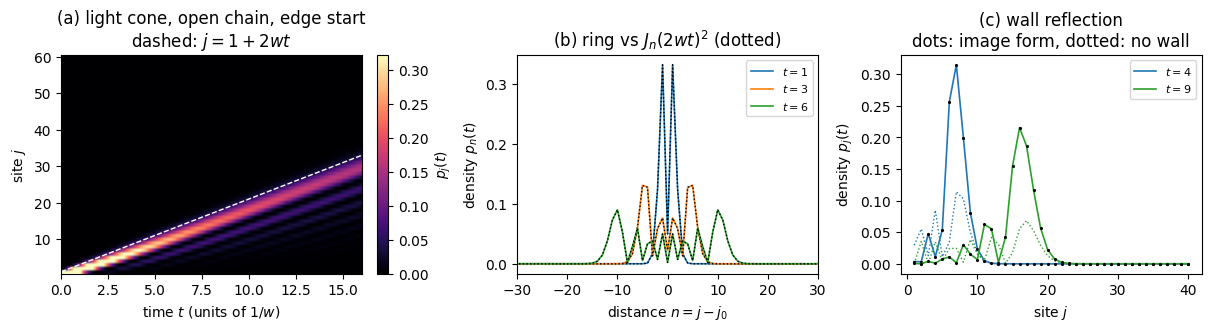

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)

N, T = 60, 16.0
ts = np.linspace(0, T, 260)
H = hop(N, periodic=False)
dens = np.array([np.abs(expm(-1j * H * t) @ np.eye(N)[0]) ** 2 for t in ts])
im = ax[0].imshow(dens.T, origin="lower", aspect="auto", cmap="magma",
                  extent=[0, T, 0.5, N + 0.5], vmax=np.percentile(dens, 99.5))
ax[0].plot(ts, 1 + 2 * W * ts, "--", color="white", lw=1.0)
ax[0].set_ylim(0.5, N + 0.5); ax[0].set_xlabel(r"time $t$ (units of $1/w$)"); ax[0].set_ylabel(r"site $j$")
ax[0].set_title("(a) light cone, open chain, edge start\n" + r"dashed: $j = 1 + 2wt$")
fig.colorbar(im, ax=ax[0], label=r"$p_j(t)$")

N = 200; H = hop(N, periodic=True); c0 = np.eye(N)[N // 2]; d = np.arange(N) - N // 2
for t in (1.0, 3.0, 6.0):
    ax[1].plot(d, np.abs(expm(-1j * H * t) @ c0) ** 2, "-", lw=1.2, label=f"$t={t:g}$")
    ax[1].plot(d, jv(np.abs(d), 2 * W * t) ** 2, ":", color="black", lw=1.0)
ax[1].set_xlim(-30, 30); ax[1].set_xlabel(r"distance $n = j - j_0$"); ax[1].set_ylabel(r"density $p_n(t)$")
ax[1].set_title("(b) ring vs $J_n(2wt)^2$ (dotted)"); ax[1].legend(fontsize=8)

N = 40; H = hop(N, periodic=False)
jj_c = np.arange(1, N + 1)
for t, col in ((4.0, "C0"), (9.0, "C2")):
    ax[2].plot(jj_c, np.abs(expm(-1j * H * t) @ np.eye(N)[0]) ** 2, "-", color=col, lw=1.2, label=f"$t={t:g}$")
    ax[2].plot(jj_c, jv(jj_c - 1, 2 * W * t) ** 2, ":", color=col, lw=1.0)                       # no wall
    ax[2].plot(jj_c, (jj_c / (W * t)) ** 2 * jv(jj_c, 2 * W * t) ** 2, ".", color="black", ms=2.5)   # image form
ax[2].set_xlabel(r"site $j$"); ax[2].set_ylabel(r"density $p_j(t)$")
ax[2].set_title("(c) wall reflection\ndots: image form, dotted: no wall"); ax[2].legend(fontsize=8)
plt.show()

Panel (a) is the light cone. The excitation starts on the edge site $j=1$ of a 60-site chain and its front follows the
dashed line $j=1+2wt$, the maximal group velocity $2w$; behind the front the density oscillates, the decaying tail
described in Section 4. The front reaches the far end near $t=(N-1)/2w=29.5$, outside the time window $t\le16$ shown,
so no reflection is seen. Panel (b) cuts through the ring at three times: the computed density (solid) lies on
$J_n(2wt)^2$ (dotted), with the largest weight just inside the edge $\vert n\vert\approx2wt$ and almost nothing beyond it. Panel (c) is the edge start
of Section 3.1 on 40 sites: the dotted curves are the infinite-chain form $J_{j-1}(2wt)^2$, which ignores the wall and
misses the computed density at both times, while the image form $(j/wt)^2J_j(2wt)^2$, the black dots, lies on the solid
curves to better than $10^{-15}$, as the table above showed. The dotted curves are drawn in the colour of the solid
curve at the same time. The computed front is about three times higher than the no-wall front (2.8 at $t=4$, 3.2 at
$t=9$), on its way to the factor 4 of Section 3.1.

## 5. The effective mass, the sign of w, the level spacing and the normalisation

**The continuum limit and the effective mass.** For $w>0$ the band has its minimum at $k=\pi$, where
$\cos(\pi+q) \simeq -1 + q^2/2$ and so $E_{\pi+q} \simeq -2w + w q^2$. Comparing the $q^2$ term with the free-particle
$E = q^2/2m$ of notebook 00a (in its units, $\hbar=1$, and here the lattice spacing is the unit of length) gives
$1/(2m_{\rm eff}) = w$, i.e.

$$ m_{\rm eff} = \frac{1}{2w}, $$

the mass that the curvature of the band imitates. A state built from momenta near the band bottom therefore moves like
a free particle, which is the continuum limit of the lattice.

**The sign of $w$, and why it is not quite immaterial.** The relabelling $c_j \to (-1)^j c_j$ sends
$e^{ikj} \to e^{i(k+\pi)j}$, shifting every momentum by $\pi$ and so turning the cosine over. On a ring it is an exact
unitary equivalence between $+w$ and $-w$ *when $N$ is even*, because the allowed set $\{2\pi m/N\}$ is then mapped
onto itself. For odd $N$ it is not: the closing bond picks up $(-1)^{N-1}=+1$ and keeps its old sign, so the two
spectra genuinely differ. This is the smallest instance of frustration on an odd ring, and it matters here because the
three-point Laplacian of notebook 00a corresponds to $w = -1/(2\Delta x^2) < 0$, whose band bottom sits at $k=0$ rather
than $k=\pi$. Near that minimum $E\simeq{\rm const}+\vert w\vert k^2$ with $k$ the lattice momentum; restoring the grid
spacing, $k = k_{\rm phys}\Delta x$, gives $\vert w\vert\Delta x^2k_{\rm phys}^2 = k_{\rm phys}^2/2$, so the grid reproduces the
mass $m=1$ it was built for.

**The level spacing.** Differentiating $E_m = 2w\cos q_m$ with respect to $m$ gives $\vert dE/dm\vert = 2w\sin(q_m)\pi/(N+1)$,
which near the band centre $q_m \simeq \pi/2$ is $2\pi w/(N+1)=\pi v/(N+1)$, with $v=2w$ the group velocity there. The
levels of a finite chain therefore crowd together as $1/N$. A many-body gap built from such levels inherits the $1/N$,
but its prefactor depends on where the lowest excitation sits. In the XX chain of
[notebook 06](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) (Eqs. (13)-(14) there, this band with
$w=2J$) the ground state fills the negative levels, zero energy lies halfway between two levels, and the gap is half a
spacing, $\Delta_N=4J\sin[\pi/(2(N+1))]\simeq\pi v/(2(N+1))$ with $v=4J$. At the critical point of the transverse-field
Ising chain in [notebook 47](../ch13_quantum_phase_transitions/47_quantum_phase_transitions.ipynb), where the dispersion is
linear rather than a cosine, the open-chain gap is likewise $\Delta\simeq\pi v/(2N)$. The scaling $v/N$ follows from
dimensional analysis alone (a velocity and a length are the only scales); the factor $\pi/2$ needs the boundary
condition.

**The normalisation.** $\sum_{j=1}^{N}\sin^2(q_m j) = (N+1)/2$ for every $m$, which is what fixes the prefactor
$\sqrt{2/(N+1)}$ of Section 3. It follows from $\sin^2 = (1-\cos)/2$ together with $\sum_{j=1}^{N}\cos(2q_m j) = -1$.

In [10]:
print("effective mass from the computed ring spectrum: lowest level (k=pi) and the next one (k = pi +- 2 pi/N)")
for N in (20, 40, 100, 200):
    E = np.sort(np.linalg.eigvalsh(hop(N, periodic=True, w=W)))   # N even: E[0] at k=pi, E[1]=E[2] at q = 2 pi/N
    q = 2 * np.pi / N
    curv = (E[1] - E[0]) / q**2
    print(f"  N={N:4d}, q={q:6.4f}: (E_1 - E_0)/q^2 = {curv:.6f}   predicted w = {W}"
          f"    ->  m_eff = {1/(2*curv):.6f}   predicted 1/2w = {1/(2*W):.6f}")
assert abs(curv - W) < 1e-3 and abs(curv - 2 * W) > 0.5      # wrong control: m_eff = 1/w would fail

print("\nsign of w: is c_j -> (-1)^j c_j a unitary equivalence between +w and -w on a ring?")
for N in (8, 9, 12, 13, 200, 201):
    U = np.diag([(-1.0) ** j for j in range(N)])
    gauge = np.abs(U @ hop(N, True, +W) @ U - hop(N, True, -W)).max()
    dspec = np.abs(np.sort(np.linalg.eigvalsh(hop(N, True, +W)))
                   - np.sort(np.linalg.eigvalsh(hop(N, True, -W)))).max()
    print(f"  N={N:4d} ({'even' if N % 2 == 0 else ' odd'}): max|U H(+w) U - H(-w)| = {gauge:.1f}"
          f"   max spectral difference = {dspec:.2e}")
print("  N=3, the smallest frustrated ring:", np.round(np.linalg.eigvalsh(hop(3, True, +W)), 6),
      "against", np.round(np.linalg.eigvalsh(hop(3, True, -W)), 6))

print("\nlevel spacing near the band centre, against 2 pi w/(N+1)")
for N in (12, 40, 200):
    q = np.pi * np.arange(1, N + 1) / (N + 1)
    E = 2 * W * np.cos(q)
    mid = N // 2
    print(f"  N={N:4d}: |E[mid]-E[mid-1]| = {abs(E[mid]-E[mid-1]):.6f}"
          f"   2 pi w/(N+1) = {2*np.pi*W/(N+1):.6f}   ratio {abs(E[mid]-E[mid-1])/(2*np.pi*W/(N+1)):.4f}")

print("\nnormalisation: sum_j sin^2(q_m j) should be (N+1)/2 for every m")
for N in (12, 40):
    q = np.pi * np.arange(1, N + 1) / (N + 1)
    j = np.arange(1, N + 1)
    sums = np.array([np.sum(np.sin(qm * j) ** 2) for qm in q])
    print(f"  N={N:3d}: (N+1)/2 = {(N+1)/2:6.1f};  max deviation over all m = {np.abs(sums-(N+1)/2).max():.2e}")
    phi = np.sqrt(2/(N+1)) * np.sin(np.outer(q, j))
    print(f"         orthonormality max|phi phi^T - I| = {np.abs(phi @ phi.T - np.eye(N)).max():.2e}")

effective mass from the computed ring spectrum: lowest level (k=pi) and the next one (k = pi +- 2 pi/N)
  N=  20, q=0.3142: (E_1 - E_0)/q^2 = 0.991802   predicted w = 1.0    ->  m_eff = 0.504133   predicted 1/2w = 0.500000
  N=  40, q=0.1571: (E_1 - E_0)/q^2 = 0.997946   predicted w = 1.0    ->  m_eff = 0.501029   predicted 1/2w = 0.500000
  N= 100, q=0.0628: (E_1 - E_0)/q^2 = 0.999671   predicted w = 1.0    ->  m_eff = 0.500165   predicted 1/2w = 0.500000
  N= 200, q=0.0314: (E_1 - E_0)/q^2 = 0.999918   predicted w = 1.0    ->  m_eff = 0.500041   predicted 1/2w = 0.500000

sign of w: is c_j -> (-1)^j c_j a unitary equivalence between +w and -w on a ring?
  N=   8 (even): max|U H(+w) U - H(-w)| = 0.0   max spectral difference = 0.00e+00
  N=   9 ( odd): max|U H(+w) U - H(-w)| = 2.0   max spectral difference = 6.95e-01
  N=  12 (even): max|U H(+w) U - H(-w)| = 0.0   max spectral difference = 0.00e+00
  N=  13 ( odd): max|U H(+w) U - H(-w)| = 2.0   max spectral difference = 4.82e-01
  N=

The curvature read from the computed ring spectrum approaches $w$ as $w(1-q^2/12)$, the next term of the cosine
($0.99180$ at $N=20$, $0.99992$ at $N=200$), so $m_{\rm eff}\to1/(2w)$; the control $m_{\rm eff}=1/w$ is excluded
by the assert. On even rings the sign change is an exact gauge transformation and the spectra coincide; on odd rings
the closing bond keeps its sign and the spectra differ, by an amount that shrinks with $N$ ($0.70$, $0.48$, $0.031$ for
$N=9,13,201$) because a single frustrated bond matters less on a longer ring. The level spacing at the band centre
approaches $2\pi w/(N+1)$ with ratios $0.9976$, $0.9998$, $1.0000$, and the normalisation and orthonormality of
the standing waves hold to $10^{-13}$ or better.

## 6. Where the hopping matrix returns: magnons, free fermions and tensor networks

The XX spin chain, $\hat H = J\sum_j(\hat X_j\hat X_{j+1} + \hat Y_j\hat Y_{j+1})$, commutes with $\sum_j\hat Z_j$, so
the number of reversed spins is conserved (notebook 03, Section 6.2; the magnetisation sectors are defined in its
Section 4.3). With $\sigma^\pm=(\hat X\pm i\hat Y)/2$ one has

$$ \hat X_j\hat X_{j+1}+\hat Y_j\hat Y_{j+1} = 2\big(\sigma^+_j\sigma^-_{j+1}+\sigma^-_j\sigma^+_{j+1}\big), $$

so each bond moves a reversed spin to the neighbouring site with amplitude $2J$ and does nothing else; there is no
diagonal term, because the chain has no $\hat Z_j\hat Z_{j+1}$ coupling. Starting from all spins up with one reversed,
the state stays in the one-reversed-spin sector for ever. Label the $N$ states of that sector by the position $j$ of
the reversed spin: the $2^N$-dimensional Hamiltonian restricted to them is the matrix of this notebook with $w = 2J$,
the band becomes $E_k = 4J\cos k$ and the propagator $(-i)^nJ_n(4Jt)$. A many-body problem whose state vector has
$2^N$ amplitudes has collapsed onto an $N\times N$ one by symmetry. The excitation is then called a *magnon*.

The Jordan-Wigner transformation, quoted in notebook 06, extends this from one excitation to any number, making the XX
chain a gas of non-interacting fermions hopping on the same lattice. The one-magnon result is the special case in which
a single level is occupied.

The practical use is different. Notebook 18 (Section 10.1) evolves matrix product states of 60-spin XX chains and
measures their error against the free-fermion solution, whose only input is the single-particle propagator
$e^{-i\hat Ht}$ of this matrix with $w=2J$, a $60\times60$ problem. A state with one excitation is the simplest such
test, for a further reason. Cutting the chain after its first $l$ sites ($j=0,\dots,l-1$ in the zero-based labels of the
code) splits the state into two terms only,

$$ \vert\psi\rangle = \sqrt{P_L}\,\vert\phi_L\rangle\otimes\vert{\uparrow\cdots\uparrow}\rangle
   + \sqrt{P_R}\,\vert{\uparrow\cdots\uparrow}\rangle\otimes\vert\phi_R\rangle,
   \qquad P_L=\sum_{j<l}\vert c_j\vert^2,\quad P_R = 1-P_L, $$

where $\vert\phi_L\rangle\propto\sum_{j<l}c_j\vert j\rangle$ is the normalised state of the left block with the excitation
in it and $\vert\phi_R\rangle$ likewise on the right. On each side the two states that appear (one excitation, or none)
are orthogonal. This is a Schmidt decomposition, so the Schmidt rank is at
most two, the Schmidt values are $\sqrt{P_L}$ and $\sqrt{P_R}$, the entanglement entropy is at most one bit, and a matrix
product state of bond dimension two is exact at every time. The Trotterised time evolution of TEBD conserves
$\sum_j\hat Z_j$ as well, so the state never leaves the sector. A disagreement between TEBD at bond dimension two and the
Bessel function, beyond the Trotter error, therefore locates a mistake in the implementation, with truncation ruled out
in advance.

The cell below checks both statements on $N=8$ spins. It builds the XX Hamiltonian as a dense $256\times256$ matrix from
Kronecker products (the textbook construction of notebook 03; qubit 0 is the most significant bit, $\vert0\rangle$ is spin
up), takes the rows and columns of the eight states with one reversed spin, and compares the block with `hop(8, w=2J)`.
It then evolves one such state with the full spin Hamiltonian and computes the Schmidt values across every cut from a
singular-value decomposition. The wrong controls are $w=J$, which forgets the factor 2 of $\sigma^\pm$, and a state with
two reversed spins, whose Schmidt rank exceeds two.

In [11]:
from functools import reduce

X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]])
I2 = np.eye(2)

def site_op(op, j, N):
    """op acting on spin j of N, as a dense 2^N x 2^N matrix (spin 0 = most significant bit)."""
    return reduce(np.kron, [op if q == j else I2 for q in range(N)])

def xx_chain(N, J=1.0, periodic=False):
    """H = J sum_<j,j+1> (X_j X_{j+1} + Y_j Y_{j+1}), dense; the ring adds the bond (N-1, 0)."""
    bonds = [(j, j + 1) for j in range(N - 1)] + ([(N - 1, 0)] if periodic else [])
    return sum(J * (site_op(X, a, N) @ site_op(X, b, N) + site_op(Y, a, N) @ site_op(Y, b, N)) for a, b in bonds)

N, J = 8, 0.7
one_flip = [1 << (N - 1 - j) for j in range(N)]           # basis index of |up..up down(at j) up..up>
for periodic in (False, True):
    Hs = xx_chain(N, J, periodic)
    block = Hs[np.ix_(one_flip, one_flip)]
    leak = np.abs(np.delete(Hs[:, one_flip], one_flip, axis=0)).max()   # elements leading OUT of the sector
    err = np.abs(block - hop(N, periodic, 2 * J)).max()
    err_wrong = np.abs(block - hop(N, periodic, J)).max()
    print(f"{'ring' if periodic else 'open'}: max|block - hop(w=2J)| = {err:.1e}   leak out of sector = {leak:.1e}"
          f"   wrong control hop(w=J): {err_wrong:.2f}")
    assert err < TOL and leak < TOL and err_wrong > 0.1

# one reversed spin at site 2, evolved with the FULL spin Hamiltonian (open chain)
Hs = xx_chain(N, J)
psi = expm(-1j * Hs * 1.3) @ np.eye(2 ** N)[one_flip[2]]
c = psi[one_flip]                                          # the N amplitudes of the sector
print(f"\nweight outside the sector: {1 - np.sum(np.abs(c)**2):.1e};"
      f"  max|c - e^(-i hop(2J) t) c(0)| = {np.abs(c - expm(-1j * hop(N, False, 2*J) * 1.3) @ np.eye(N)[2]).max():.1e}")
psi2 = expm(-1j * Hs * 1.3) @ np.eye(2 ** N)[one_flip[2] + one_flip[5]]   # wrong control: two reversed spins
for l in range(1, N):
    sv = np.linalg.svd(psi.reshape(2 ** l, -1), compute_uv=False)
    PL = np.sum(np.abs(c[:l]) ** 2)
    rank1 = np.sum(sv > 1e-12)
    rank2 = np.sum(np.linalg.svd(psi2.reshape(2 ** l, -1), compute_uv=False) > 1e-12)
    pred = np.sort([np.sqrt(PL), np.sqrt(1 - PL)])[::-1]
    print(f"  cut after {l} spins: Schmidt rank {rank1}, values {sv[0]:.6f} {sv[1]:.6f}  vs sqrt(P_L), sqrt(P_R):"
          f" {pred[0]:.6f} {pred[1]:.6f};   two reversed spins: rank {rank2}")
    assert rank1 <= 2 and np.abs(sv[:2] - pred).max() < TOL
    assert rank2 > 2 or l in (1, N - 1)

open: max|block - hop(w=2J)| = 0.0e+00   leak out of sector = 0.0e+00   wrong control hop(w=J): 0.70
ring: max|block - hop(w=2J)| = 0.0e+00   leak out of sector = 0.0e+00   wrong control hop(w=J): 0.70



weight outside the sector: -2.2e-16;  max|c - e^(-i hop(2J) t) c(0)| = 4.7e-16


  cut after 1 spins: Schmidt rank 2, values 0.747275 0.664515  vs sqrt(P_L), sqrt(P_R): 0.747275 0.664515;   two reversed spins: rank 2
  cut after 2 spins: Schmidt rank 2, values 0.747129 0.664679  vs sqrt(P_L), sqrt(P_R): 0.747129 0.664679;   two reversed spins: rank 4
  cut after 3 spins: Schmidt rank 2, values 0.757956 0.652306  vs sqrt(P_L), sqrt(P_R): 0.757956 0.652306;   two reversed spins: rank 4
  cut after 4 spins: Schmidt rank 2, values 0.762974 0.646430  vs sqrt(P_L), sqrt(P_R): 0.762974 0.646430;   two reversed spins: rank 4
  cut after 5 spins: Schmidt rank 2, values 0.881004 0.473109  vs sqrt(P_L), sqrt(P_R): 0.881004 0.473109;   two reversed spins: rank 4
  cut after 6 spins: Schmidt rank 2, values 0.969219 0.246201  vs sqrt(P_L), sqrt(P_R): 0.969219 0.246201;   two reversed spins: rank 4
  cut after 7 spins: Schmidt rank 2, values 0.994770 0.102136  vs sqrt(P_L), sqrt(P_R): 0.994770 0.102136;   two reversed spins: rank 2


In the sector with one reversed spin the spin Hamiltonian is `hop(N, w=2J)` to rounding, on the open chain and on the ring,
and no matrix element leads out of the sector. The control `hop(N, w=J)` differs by $J=0.7$, the size of the missing half
of the amplitude. After evolution with the full $256\times256$ Hamiltonian the eight sector amplitudes coincide with the
$8\times8$ propagator. Across every cut the state has exactly two non-zero Schmidt values, equal to $\sqrt{P_L}$ and
$\sqrt{P_R}$, while a state with two reversed spins reaches rank four at the inner cuts (at the outermost
cuts one side is a single spin, so no state can exceed rank two there).

## 7. Summary

### Key takeaways

* **One excitation on $N$ sites is an $N\times N$ problem.** The hopping Hamiltonian $w\sum_j(\vert j\rangle\langle j+1\vert+{\rm h.c.})$
  is the three-point Laplacian of notebook 00a read as physics rather than as an approximation; its "numerical
  dispersion" is the band $E_k=2w\cos k$, of width $4w$.
* **Ring: plane waves.** $k=2\pi m/N$, and the propagator from one site is $G_n(t)=(-i)^nJ_n(2wt)$ on an infinite chain,
  obtained from the Jacobi-Anger expansion; the matrix exponential reproduces it to $10^{-15}$ while the ring is
  effectively infinite, and the wrong phase $(+i)^n$ fails at order one.
* **Open chain: standing waves.** $q_m=m\pi/(N+1)$, the same cosine band, and a propagator that is an exact $N$-term
  sum at every $N$ and $t$, reflections included.
* **A wall acts from the first instant.** For a release on the edge site the free Bessel form is wrong by $0.1$–$0.3$ at
  all times; the method of images gives $p_j=(j/wt)^2J_j(2wt)^2$, exact until the front reaches the far end, with a
  front about twice as high in amplitude because the left-moving half is reflected.
* **The light cone has speed $2w$ and an Airy edge.** Stationary phase selects the plane waves whose group velocity
  $-2w\sin k$ carries them to site $n$ at time $t$; none exist for $\vert n\vert>2wt$. At the front the density follows
  $\mathrm{Ai}$, and the density at site $n$ peaks at $2wt\simeq n+0.8086\,n^{1/3}$, confirmed to within the next
  asymptotic term.
* **Band bottom, sign and spacing.** The band bottom gives $m_{\rm eff}=1/(2w)$; $w\to-w$ is a gauge transformation on
  even rings only; levels are spaced by $\pi v/(N+1)$ near the band centre, which gives the $1/N$ gaps of the XX and
  critical Ising chains with a boundary-dependent prefactor.
* **The matrix returns.** The one-magnon sector of the XX chain is this matrix with $w=2J$ (checked on the full
  $2^8$-dimensional spin Hamiltonian); free fermions generalise it to many excitations; one excitation has Schmidt rank
  two across every cut, so bond dimension two is exact.

### Exercises

1. (★) **The band of a ring.** Diagonalise the ring Hamiltonian for $N=8,16,64$ and check the eigenvalues against
   $2w\cos(2\pi m/N)$. Then verify that the plane waves $\vert k\rangle$ of Section 2 are eigenvectors without
   diagonalising anything, by applying the matrix to them.
2. (★) **An on-site energy.** Add a diagonal term $\epsilon\sum_j\vert j\rangle\langle j\vert$. Predict how the band,
   the propagator $G_n(t)$ and the density $p_j(t)$ change, check the predictions numerically, and name a measurement
   that could detect $\epsilon$ at all.
3. (★★) **The Bessel front.** Release an excitation at the centre of a ring of 200 sites and measure, for each of
   $n=5,10,20,40$, the time at which the density at site $n$ is largest. Compare with the arrival time $n/2w$ and with
   the Airy edge, Eq. (F) of Section 4.1. How large must $t$ be before the ring is no longer equivalent to the infinite
   chain?
4. (★★) **Reflection at a wall.** Release the excitation on the middle site $j=21$ of an open chain of $N=41$ sites.
   Predict from the maximal group velocity the time at which the two reflected fronts meet again at the centre, then
   measure it as the time of the largest peak of $p_{21}(t)$ after the initial decay. Then release the excitation on the
   edge site $j=1$, predict and measure the time at which its front first returns to site 1, and explain why this time
   is about twice the first one. (Use the method of images of Section 3.1 for the prediction, and the Airy delay of
   Section 4 for the difference between prediction and measurement.)
5. (★★) **A dimerised chain.** Replace the uniform hopping by $w_j = w(1+(-1)^j\delta)$ and compute the spectrum. Show
   that a gap opens at $k=\pi/2$, find its size as a function of $\delta$, and measure the group velocity at the gap
   edge. What happens to the light cone, i.e. to the maximal group velocity? (Hint: the chain now repeats itself every two sites, so try
   $c_{2l}=a\,e^{2ikl}$, $c_{2l+1}=b\,e^{2ikl}$; the eigenvalue equation becomes a $2\times2$ matrix for $(a,b)$.)
6. (★★) **The continuum limit.** Section 5 found the effective mass $m_{\rm eff}=1/(2w)$ at the band bottom $k=\pi$. On an
   open chain of 800 sites prepare the packet $c_j\propto e^{-(j-j_0)^2/4\sigma_0^2}\,e^{i\pi j}$ centred at $j_0=400$,
   which is built from momenta near $k=\pi$, and measure its width $\sigma(t)$ up to $t=40$ for $\sigma_0=1,2,5$.
   Compare with the spreading law of a free Gaussian packet of notebook 00a with the mass $m_{\rm eff}$,
   $\sigma(t)=\sigma_0\sqrt{1+(wt/\sigma_0^2)^2}$. Explain why the agreement improves as $\sigma_0$ grows, and why an
   excitation started on a single site, which contains every $k$ with equal weight, never follows this law.
7. (★★★) **Bloch oscillations.** Add a linear potential, $\epsilon_j = Fj$. The excitation no longer escapes but
   oscillates. Predict the period from the band and measure it for $F=0.1,0.2,0.5$. (Hint: the potential multiplies a
   plane wave $e^{ikj}$ by the phase $e^{-iFjt}$, which is a plane wave with $k\to k-Ft$, and $k$ is defined only
   modulo $2\pi$.)

### References

* N. W. Ashcroft and N. D. Mermin, *Solid State Physics*, Holt, Rinehart and Winston (1976) — Chapter 8 (Bloch's
  theorem), Chapter 10 (the tight-binding method and its cosine bands) and Chapter 12 (the semiclassical model, in
  which a wave packet moves with the group velocity of its band).
* F. W. J. Olver et al. (eds.), *NIST Digital Library of Mathematical Functions*, https://dlmf.nist.gov/ —
  §10.12 (the generating function and Jacobi-Anger expansions), §10.19(iii) (Bessel functions in the transition region,
  in terms of Airy functions), Eq. 10.21.40 (the first maximum $j'_{\nu,1}$ for large order), and Chapter 9 (Airy
  functions).
* E. H. Lieb and D. W. Robinson, *The finite group velocity of quantum spin systems*, Commun. Math. Phys. **28**,
  251–257 (1972) — the general light cone of lattice Hamiltonians with local terms.
* V. Hunyadi, Z. Rácz and L. Sasvári, *Dynamic scaling of fronts in the quantum XX chain*, Phys. Rev. E **69**, 066103
  (2004) — fronts in the XX chain after a step-like initial magnetisation: the front region widens as $t^{1/3}$, the
  many-particle counterpart of the Airy edge of Section 4.
* E. Lieb, T. Schultz and D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**, 407–466
  (1961) — the XX chain as free fermions.
* H. B. Perets, Y. Lahini, F. Pozzi, M. Sorel, R. Morandotti and Y. Silberberg, *Realization of quantum walks with
  negligible decoherence in waveguide lattices*, Phys. Rev. Lett. **100**, 170506 (2008) — light in a lattice of about
  100 coupled waveguides obeys this model; ballistic spreading and boundary effects observed.
* T. Fukuhara et al., *Quantum dynamics of a mobile spin impurity*, Nat. Phys. **9**, 235–241 (2013) — a single spin
  excitation propagating coherently in a one-dimensional lattice of ultracold atoms, imaged with single-site resolution.
* W. P. Su, J. R. Schrieffer and A. J. Heeger, *Solitons in polyacetylene*, Phys. Rev. Lett. **42**, 1698–1701 (1979)
  — the dimerised chain of Exercise 5.
* T. Hartmann, F. Keck, H. J. Korsch and S. Mossmann, *Dynamics of Bloch oscillations*, New J. Phys. **6**, 2 (2004) —
  Exercise 7.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/